In [ ]:
#6.1.1 LeNet
#런타임을 GPU로 변경하여 실행

In [ ]:
# 라이브러리 및 모듈 불러오기
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm
import random
from matplotlib import pyplot as plt


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# 클래스 정의
class ImageTransform():
    # 생성자 함수
    def __init__(self, resize, mean, std):
        self.data_transform = {
            # 이미지 전처리 파이프라인 구성
            'train': transforms.Compose([
                # 이미지 랜덤 크롭 및 리사이즈
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                # 좌우 반전 데이터 증강
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                # 평균과 표준편차 기반 정규화
                transforms.Normalize(mean, std)
            ]),
            # 이미지 전처리 파이프라인 구성
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                # 평균과 표준편차 기반 정규화
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

# 직접 업로드

In [ ]:
# [로컬 실행] Colab 파일 업로드 불필요 — 데이터는 chap06/data/ 에 이미 압축 해제되어 있습니다.
# (Colab에서 실행할 경우) 아래 주석을 해제하세요.
# from google.colab import files
# file_uploaded = files.upload()   # dogs-vs-cats.zip 업로드

# 구글드라이브 마운트

In [ ]:
# [로컬 실행] 구글드라이브 마운트 불필요
# (Colab에서 실행할 경우) 아래 주석을 해제하세요.
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import os

# [로컬 실행] 노트북 기준 data 폴더로 작업 경로 이동
#   (jupyter를 repo 루트 / chap06 / chap06/data 어디서 실행해도 동작)
# (Colab) os.chdir('/content/drive/MyDrive/제주대/CVClass/6장발표/data/')
for _cand in ['data', '.', 'chap06/data', '../chap06/data']:
    if os.path.isdir(os.path.join(_cand, 'dogs-vs-cats')):
        os.chdir(_cand)
        break

# 현재 위치 확인
print(os.getcwd())

In [ ]:
cat_directory = 'dogs-vs-cats/Cat/'
dog_directory = 'dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
# OpenCV로 이미지 읽기
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
#train_images_filepaths = correct_images_filepaths[:20000] #성능을 향상시키고 싶다면 훈련 데이터셋을 늘려서 테스트해보세요
#val_images_filepaths = correct_images_filepaths[20000:-10] #훈련과 함께 검증도 늘려줘야 합니다
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

In [ ]:
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    # matplotlib 시각화 코드
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        # OpenCV로 이미지 읽기
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        color = "green" if true_label == predicted_label else "red"
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off()
    # matplotlib 시각화 코드
    plt.tight_layout()
    # matplotlib 시각화 코드
    plt.show()

In [ ]:
display_image_grid(test_images_filepaths)

In [ ]:
# 클래스 정의
class DogvsCatDataset(Dataset):
    # 생성자 함수
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    # 데이터셋 길이 반환
    def __len__(self):
        return len(self.file_list)

    # 데이터 하나를 반환하는 함수
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

In [ ]:
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [ ]:
from PIL import Image
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
# 데이터 하나를 반환하는 함수
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

In [ ]:
# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

In [ ]:
# 클래스 정의
class LeNet(nn.Module):
    # 생성자 함수
    def __init__(self):
        # 생성자 함수
        super(LeNet, self).__init__()
        # 합성곱(Convolution) 레이어 정의
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
        # 활성화 함수(ReLU)
        self.relu1 = nn.ReLU()
        # 최대 풀링(Max Pooling) 레이어 정의
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        # 합성곱(Convolution) 레이어 정의
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        # 활성화 함수(ReLU)
        self.relu2 = nn.ReLU() # activation
        # 최대 풀링(Max Pooling) 레이어 정의
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        # 완전연결(Fully Connected) 레이어 정의
        self.fc1 = nn.Linear(32*53*53, 512)
        # 활성화 함수(ReLU)
        self.relu5 = nn.ReLU()
        # 완전연결(Fully Connected) 레이어 정의
        self.fc2 = nn.Linear(512, 2)
        self.output = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.output(out)
        return out

LeNet 초기에는 Sigmoid나 Tanh 사용. 이 때문에 층이 깊어지면 미분값이 0으로 수렴하는 기울기 소실(Vanishing Gradient) 문제가 발생해 망을 깊게 쌓을 수 없었음

In [ ]:
!pip install IPython

In [ ]:
# 교재 그림 시각화
from IPython.display import Image as PyImage  # from PIL import Image 충돌로 별칭 사용
PyImage('246.jpg')

In [ ]:
model = LeNet().to(device)
print(model)

In [ ]:
!pip install torchsummary

In [ ]:
# 라이브러리 및 모듈 불러오기
from torchsummary import summary
# 모델 구조 요약 출력
summary(model, input_size=(3, 224, 224))

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

In [ ]:
# 옵티마이저 설정
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# 다중 분류용 손실 함수
criterion = nn.CrossEntropyLoss()

In [ ]:
# 모델을 GPU 또는 CPU 장치로 이동
# model = model.to(device)
# 손실 함수를 GPU 또는 CPU 장치로 이동
criterion = criterion.to(device)

In [ ]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):

    # 전체 학습 시작 시간 저장 (총 학습 시간 계산용)
    since = time.time()

    # 가장 높은 validation accuracy 저장 변수
    best_acc = 0.0

    # epoch 만큼 전체 데이터셋 반복 학습
    # epoch 1번 = train 데이터 전체를 한 바퀴 학습
    for epoch in range(num_epoch):

        # 현재 epoch 진행 상황 출력
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        # train phase와 validation phase를 각각 수행
        # train: 가중치 업데이트 수행
        # val: 성능 평가만 수행
        for phase in ['train', 'val']:

            # train mode 설정
            # Dropout, BatchNorm 등이 학습 모드로 동작
            if phase == 'train':
                model.train()

            # evaluation mode 설정
            # Dropout 비활성화, BatchNorm 고정
            else:
                model.eval()

            # 현재 epoch의 총 loss 누적 변수
            epoch_loss = 0.0

            # 현재 epoch의 정답 개수 누적 변수
            epoch_corrects = 0

            # dataloader에서 batch 단위로 데이터 가져오기
            # inputs : 이미지 데이터
            # labels : 정답 클래스
            for inputs, labels in tqdm(dataloader_dict[phase]):

                # 데이터를 GPU 또는 CPU 장치로 이동
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 이전 batch의 gradient 초기화
                # gradient가 누적되는 것을 방지
                optimizer.zero_grad()

                # train phase일 때만 gradient 계산 활성화
                # validation에서는 gradient 계산 비활성화하여 메모리 절약
                with torch.set_grad_enabled(phase == 'train'):

                    # 모델에 입력 데이터를 넣어 예측값 계산 (Forward Propagation)
                    outputs = model(inputs)

                    # 가장 높은 확률 값을 가진 클래스 index 선택
                    # outputs 예시:
                    # [[0.1, 0.9],
                    #  [0.8, 0.2]]
                    # preds 결과:
                    # [1, 0]
                    _, preds = torch.max(outputs, 1)

                    # 예측값과 실제 정답을 비교하여 loss 계산
                    loss = criterion(outputs, labels)

                    # train phase일 때만 역전파 및 가중치 업데이트 수행
                    if phase == 'train':

                        # loss를 기준으로 gradient 계산 (Backpropagation)
                        loss.backward()

                        # optimizer를 이용하여 weight 업데이트
                        optimizer.step()

                    # batch loss 누적
                    # loss.item() : tensor 값을 숫자로 변환
                    # inputs.size(0) : 현재 batch 크기
                    epoch_loss += loss.item() * inputs.size(0)

                    # 맞춘 정답 개수 누적
                    # preds == labels.data 결과:
                    # [True, False, True ...]
                    epoch_corrects += torch.sum(preds == labels.data)

            # epoch 전체 평균 loss 계산
            # 전체 누적 loss / 전체 데이터 개수
            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)

            # epoch 전체 accuracy 계산
            # 전체 맞춘 개수 / 전체 데이터 개수
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

            # 현재 epoch 결과 출력
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # validation accuracy가 이전 최고 성능보다 높으면 저장
            if phase == 'val' and epoch_acc > best_acc:

                # 최고 accuracy 갱신
                best_acc = epoch_acc

                # 가장 성능 좋은 모델 weight 저장
                best_model_wts = model.state_dict()

    # 전체 학습 종료 후 총 소요 시간 계산
    time_elapsed = time.time() - since

    # 총 학습 시간 출력
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))

    # 가장 높은 validation accuracy 출력
    print('Best val Acc: {:4f}'.format(best_acc))

    # 학습 완료된 모델 반환
    return model

In [ ]:
# 라이브러리 및 모듈 불러오기
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

In [ ]:
# 라이브러리 및 모듈 불러오기, 결과 저장
import pandas as pd

id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('LesNet.csv', index=False)

In [ ]:
res.head(10)

# 기존

In [ ]:
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    # matplotlib 시각화 코드
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        # OpenCV로 이미지 읽기
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ###################################
        a = random.choice(res['id'].values)
        ###################################
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    # matplotlib 시각화 코드
    plt.tight_layout()
    # matplotlib 시각화 코드
    plt.show()

# 변경

In [36]:
import math
class_ = {0: 'cat', 1: 'dog'}

def display_image_grid(images_filepaths, predicted_labels=None, cols=5):
    """
    images_filepaths: 시각화할 이미지 경로 리스트
    predicted_labels: 모델이 예측한 확률값 배열 또는 라벨 리스트 (생략 시 파일명에서 정답 추출)
    cols: 한 행에 보여줄 이미지 개수
    """
    num_images = len(images_filepaths)
    if num_images == 0:
        print("시각화할 이미지가 없습니다.")
        return

    # 2. 행(rows) 개수 올림 계산 (소수점 올림을 해야 마지막 줄 이미지 공간이 확보됨)
    rows = math.ceil(num_images / cols)

    # 격자(Grid) 생성
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, rows * 3))

    # 1차원 배열로 평탄화하여 인덱스 접근을 쉽게 만듦
    # 이미지가 1개이거나 1행일 때를 대비해 flatten() 또는 ravel() 처리
    axes = ax.ravel() if num_images > 1 else [ax]

    for i, image_filepath in enumerate(images_filepaths):
        # 3. OpenCV로 이미지 읽기 및 RGB 변환
        image = cv2.imread(image_filepath)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 4. 파일 경로에서 정답 라벨 추출 (예: 'Cat' 또는 'Dog' 폴더명 추출)
        # os.path.normpath를 사용하여 운영체제별 경로 구분자 문제 방지
        import os
        true_label_str = os.path.normpath(image_filepath).split(os.sep)[-2].lower() # 'cat' 또는 'dog'

        # 5. 예측값 처리 (1:1 매칭 구조)
        if predicted_labels is not None and i < len(predicted_labels):
            pred_val = predicted_labels[i]
            # 만약 예측값이 확률(0.0~1.0) 형태로 들어온다면 0.5 기준으로 0과 1 변환
            if isinstance(pred_val, (int, float)):
                pred_label_idx = 1 if pred_val > 0.5 else 0
                predicted_label_str = class_[pred_label_idx]
            else:
                predicted_label_str = str(pred_val).lower()
        else:
            # 예측 라벨 인자가 없을 경우 정답 라벨을 타이틀로 임시 사용
            predicted_label_str = true_label_str

        # 6. 정답 여부에 따른 글자 색상 결정 (맞으면 초록색, 틀리면 빨간색)
        color = "green" if true_label_str == predicted_label_str else "red"

        # 이미지 및 타이틀 출력
        axes[i].imshow(image)
        axes[i].set_title(predicted_label_str, color=color, fontsize=12)
        axes[i].set_axis_off()

    # 7. 빈 서브플롯(Grid) 숨기기 (예: 이미지는 7개인데 격자는 10개일 때 남은 3개 숨김)
    for j in range(num_images, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# res 데이터프레임에서 모델이 뱉어낸 라벨 리스트를 추출하여 함수에 전달
prediction_list = res['label'].tolist()
display_image_grid(test_images_filepaths, predicted_labels=prediction_list)

In [ ]:
#6.1.3 AlexNet
#메모리 문제로 '런타임' > '런타임 다시 시작'을 해주세요

In [ ]:
# 라이브러리 및 모듈 불러오기
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
import random
import time
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm_notebook as tqdm
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# 클래스 정의
class ImageTransform():
    # 생성자 함수
    def __init__(self, resize, mean, std):
        self.data_transform = {
            # 이미지 전처리 파이프라인 구성
            'train': transforms.Compose([
                # 이미지 랜덤 크롭 및 리사이즈
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                # 좌우 반전 데이터 증강
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                # 평균과 표준편차 기반 정규화
                transforms.Normalize(mean, std)
            ]),
            # 이미지 전처리 파이프라인 구성
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                # 평균과 표준편차 기반 정규화
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

# 동일 데이터 로드

In [ ]:
cat_directory = 'dogs-vs-cats/Cat/'
dog_directory = 'dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
# OpenCV로 이미지 읽기
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
#train_images_filepaths = correct_images_filepaths[:20000] #성능을 향상시키고 싶다면 훈련 데이터셋을 늘려서 테스트해보세요
#val_images_filepaths = correct_images_filepaths[20000:-10] #훈련과 함께 검증도 늘려줘야 합니다
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

In [ ]:
# # 클래스 정의
# class DogvsCatDataset(Dataset):
#     # 생성자 함수
#     def __init__(self, file_list, transform=None, phase='train'):
#         self.file_list = file_list
#         self.transform = transform
#         self.phase = phase

#     # 데이터셋 길이 반환
#     def __len__(self):
#         return len(self.file_list)

#     # 데이터 하나를 반환하는 함수
#     def __getitem__(self, idx):
#         img_path = self.file_list[idx]
#         img = Image.open(img_path)
#         img_transformed = self.transform(img, self.phase)

#         label = img_path.split('/')[-1].split('.')[0]
#         if label == 'dog':
#             label = 1
#         elif label == 'cat':
#             label = 0

#         return img_transformed, label

In [ ]:
# size = 256
# mean = (0.485, 0.456, 0.406)
# std = (0.229, 0.224, 0.225)
# batch_size = 32

In [ ]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
# 데이터 하나를 반환하는 함수
print(train_dataset.__getitem__(index)[0].size())
# 데이터 하나를 반환하는 함수
print(train_dataset.__getitem__(index)[1])

In [ ]:
# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

In [ ]:
# 클래스 정의
class AlexNet(nn.Module):
    # 생성자 함수
    def __init__(self) -> None:
        # 생성자 함수
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # 합성곱(Convolution) 레이어 정의
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            # 최대 풀링(Max Pooling) 레이어 정의
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 합성곱(Convolution) 레이어 정의
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            # 최대 풀링(Max Pooling) 레이어 정의
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 합성곱(Convolution) 레이어 정의
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            # 합성곱(Convolution) 레이어 정의
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            # 합성곱(Convolution) 레이어 정의
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            # 최대 풀링(Max Pooling) 레이어 정의
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            # 완전연결(Fully Connected) 레이어 정의
            nn.Linear(256 * 6 * 6, 4096),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            nn.Dropout(),
            # 완전연결(Fully Connected) 레이어 정의
            nn.Linear(4096, 512),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace=True),
            # 완전연결(Fully Connected) 레이어 정의
            nn.Linear(512, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [ ]:
PyImage('272.jpg')

In [ ]:
PyImage('270.jpg')

In [ ]:
model = AlexNet()
# 모델을 GPU 또는 CPU 장치로 이동
model.to(device)

In [ ]:
# 옵티마이저 설정
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# 다중 분류용 손실 함수
criterion = nn.CrossEntropyLoss().to(device)

In [ ]:
# 라이브러리 및 모듈 불러오기
from torchsummary import summary
# 모델 구조 요약 출력
summary(model, input_size=(3, 256, 256))

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model, input_size=(32,3,256,256))

In [ ]:
!pip install torchviz

In [ ]:
import torch
from torchviz import make_dot

# 1. summary에서 사용했던 크기와 똑같은 가짜(dummy) 데이터를 만듭니다.
# (배치 사이즈 32, 컬러 채널 3, 256x256 해상도)
dummy_input = torch.randn(32, 3, 256, 256).to(device)

# 2. 모델에 가짜 데이터를 한 번 통과시켜 결과물을 뽑아냅니다.
outputs = model(dummy_input)

# 3. 모델의 결과물과 파라미터 정보를 바탕으로 연산 그래프를 그립니다.
visualized_graph = make_dot(outputs, params=dict(model.named_parameters()))

# 4. 코랩 화면에 그래프 출력
visualized_graph

# LesNet train model과 동일코드

In [ ]:
# def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
#     since = time.time()
#     best_acc = 0.0

#     # 전체 학습 epoch 반복
#     for epoch in range(num_epoch):
#         print('Epoch {}/{}'.format(epoch + 1, num_epoch))
#         print('-'*20)

#         for phase in ['train', 'val']:
#             if phase == 'train':
#                 model.train()
#             else:
#                 model.eval()

#             epoch_loss = 0.0
#             epoch_corrects = 0

#             for inputs, labels in tqdm(dataloader_dict[phase]):
#                 inputs = inputs.to(device)
#                 labels = labels.to(device)
#                 # 이전 gradient 초기화
#                 optimizer.zero_grad()

#                 with torch.set_grad_enabled(phase == 'train'):
#                     outputs = model(inputs)
#                     # 가장 높은 확률의 클래스 선택
#                     _, preds = torch.max(outputs, 1)
#                     loss = criterion(outputs, labels)

#                     if phase == 'train':
#                         # 역전파 수행
#                         loss.backward()
#                         # 가중치 업데이트
#                         optimizer.step()

#                     epoch_loss += loss.item() * inputs.size(0)
#                     epoch_corrects += torch.sum(preds == labels.data)

#             epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
#             epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

#             print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

#     time_elapsed = time.time() - since
#     print('Training complete in {:.0f}m {:.0f}s'.format(
#         time_elapsed // 60, time_elapsed % 60))
#     return model

In [ ]:
num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

In [ ]:
import pandas as pd

id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})
res.to_csv('alexnet.csv', index=False)

In [ ]:
res.head(10)

In [ ]:
# res 데이터프레임에서 모델이 뱉어낸 라벨 리스트를 추출하여 함수에 전달
prediction_list = res['label'].tolist()
display_image_grid(test_images_filepaths, predicted_labels=prediction_list)

In [ ]:
#6.1.4 VGGNet
#메모리 문제로 '런타임' > '런타임 다시 시작'을 해주세요

In [ ]:
# 라이브러리 및 모듈 불러오기
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# 클래스 정의
class VGG(nn.Module):
    # 생성자 함수
    def __init__(self, features, output_dim):
        # 생성자 함수
        super().__init__()
        self.features = features
        self.avgpool = nn.AdaptiveAvgPool2d(7)
        self.classifier = nn.Sequential(
            # 완전연결(Fully Connected) 레이어 정의
            nn.Linear(512 * 7 * 7, 4096),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            # 완전연결(Fully Connected) 레이어 정의
            nn.Linear(4096, 4096),
            # 활성화 함수(ReLU)
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            # 완전연결(Fully Connected) 레이어 정의
            nn.Linear(4096, output_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

In [ ]:
PyImage('285.jpg')

In [ ]:
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512,
                512, 'M']

vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M',
                512, 512, 512, 512, 'M']

In [ ]:
PyImage('290.jpg')

In [ ]:
def get_vgg_layers(config, batch_norm):
    layers = []
    in_channels = 3

    for c in config:
        assert c == 'M' or isinstance(c, int)
        if c == 'M':
            # 최대 풀링(Max Pooling) 레이어 정의
            layers += [nn.MaxPool2d(kernel_size = 2)]
        else:
            # 합성곱(Convolution) 레이어 정의
            conv2d = nn.Conv2d(in_channels, c, kernel_size = 3, padding = 1)
            if batch_norm:
                # 활성화 함수(ReLU)
                layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace = True)]
            else:
                # 활성화 함수(ReLU)
                layers += [conv2d, nn.ReLU(inplace = True)]
            in_channels = c

    return nn.Sequential(*layers)

In [ ]:
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm = True)

In [ ]:
print(vgg11_layers)

In [ ]:
OUTPUT_DIM = 2
model = VGG(vgg11_layers, OUTPUT_DIM).to(device)
print(model)

In [ ]:
import torchvision.models as models

pretrained_model = models.vgg11_bn(pretrained = True)
print(pretrained_model)

In [ ]:
# 이미지 전처리 파이프라인 구성
train_transforms = transforms.Compose([
                           transforms.Resize((256, 256)),
                           transforms.RandomRotation(5),
                           # 좌우 반전 데이터 증강
                           transforms.RandomHorizontalFlip(0.5),
                           transforms.ToTensor(),
                           # 평균과 표준편차 기반 정규화
                           transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

# 이미지 전처리 파이프라인 구성
test_transforms = transforms.Compose([
                           transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           # 평균과 표준편차 기반 정규화
                           transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

# 데이터 업로드 생략

In [ ]:
# # 라이브러리 및 모듈 불러오기
# from google.colab import files # 데이터 불러오기
# # Colab 환경에서 파일 업로드
# file_uploaded=files.upload()   # chap06/data/catanddog.zip 데이터 불러오기

In [ ]:
# # 압축 파일 해제
# !unzip catanddog.zip    #압축 풀기
# # 압축 파일 해제
# !unzip catanddog.zip -d catanddog/  #catanddog 폴더 만들어 압축 풀기

In [ ]:
train_path = 'catanddog/train'
test_path = 'catanddog/test'

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

In [ ]:
VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset) * VALID_RATIO)
n_valid_examples = len(train_dataset) - n_train_examples

train_data, valid_data = data.random_split(train_dataset,
                                           [n_train_examples, n_valid_examples])

In [ ]:
# deep copy 추가
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [ ]:
PyImage('288.jpg')

In [ ]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

In [ ]:
BATCH_SIZE = 32 #메모리 부족으로 오류가 발생하여 배치 사이즈를 줄였습니다
# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
train_iterator = data.DataLoader(train_data,
                                 shuffle = True,
                                 batch_size = BATCH_SIZE)

# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
valid_iterator = data.DataLoader(valid_data,
                                 batch_size = BATCH_SIZE)

# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
test_iterator = data.DataLoader(test_dataset,
                                batch_size = BATCH_SIZE)

In [ ]:
# 옵티마이저 설정
optimizer = optim.Adam(model.parameters(), lr = 1e-7)
# 다중 분류용 손실 함수
criterion = nn.CrossEntropyLoss()

# 모델을 GPU 또는 CPU 장치로 이동
model = model.to(device)
# 손실 함수를 GPU 또는 CPU 장치로 이동
criterion = criterion.to(device)

In [ ]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim = True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

train, val 분리

In [ ]:
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        # 이전 gradient 초기화
        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)
        # 역전파 수행
        loss.backward()
        # 가중치 업데이트
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
import time

EPOCHS = 5
best_valid_loss = float('inf')
# 전체 학습 epoch 반복
for epoch in range(EPOCHS):
    start_time = time.monotonic()
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'VGG-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Valid. Loss: {valid_loss:.3f} |  Valid. Acc: {valid_acc*100:.2f}%')

In [ ]:
model.load_state_dict(torch.load('VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

In [ ]:
def get_predictions(model, iterator):
    model.eval()
    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y_pred, _ = model(x)
            y_prob = F.softmax(y_pred, dim = -1)
            top_pred = y_prob.argmax(1, keepdim = True)
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim = 0)
    labels = torch.cat(labels, dim = 0)
    probs = torch.cat(probs, dim = 0)
    return images, labels, probs

In [ ]:
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels)
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if correct:
        correct_examples.append((image, label, prob))

# 가장 높은 확률의 클래스 선택
correct_examples.sort(reverse = True, key = lambda x: torch.max(x[2], dim = 0).values)

In [ ]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

In [ ]:
def plot_most_correct(correct, classes, n_images, normalize = True):
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))
    # matplotlib 시각화 코드
    fig = plt.figure(figsize = (25, 20))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)
        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0)
        true_prob = probs[true_label]
        # 가장 높은 확률의 클래스 선택
        correct_prob, correct_label = torch.max(probs, dim = 0)
        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' \
                     f'pred label: {correct_class} ({correct_prob:.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace = 0.4)

In [ ]:
classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)

In [ ]:
#GoogLeNet

In [ ]:
import torch
import torch.nn as nn

# 1. GoogLeNet의 심장: 인셉션 모듈 정의
class InceptionModule(nn.Module):
    def __init__(self, in_channels, n1x1, n3x3_reduce, n3x3, n5x5_reduce, n5x5, pool_proj):
        super().__init__()

        # 1줄 갈래: 1x1 컨볼루션
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, n1x1, kernel_size=1),
            nn.BatchNorm2d(n1x1),
            nn.ReLU(inplace=True)
        )

        # 2줄 갈래: 1x1 크기 줄이기 -> 3x3 컨볼루션
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, n3x3_reduce, kernel_size=1),
            nn.BatchNorm2d(n3x3_reduce),
            nn.ReLU(inplace=True),
            nn.Conv2d(n3x3_reduce, n3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(n3x3),
            nn.ReLU(inplace=True)
        )

        # 3줄 갈래: 1x1 크기 줄이기 -> 5x5 컨볼루션
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, n5x5_reduce, kernel_size=1),
            nn.BatchNorm2d(n5x5_reduce),
            nn.ReLU(inplace=True),
            nn.Conv2d(n5x5_reduce, n5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(n5x5),
            nn.ReLU(inplace=True)
        )

        # 4줄 갈래: 3x3 맥스풀링 -> 1x1 컨볼루션
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # 4개의 갈래로 연산을 동시에(병렬로) 수행합니다.
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        out4 = self.branch4(x)

        # 특징 맵의 채널 차원(dim=1)을 기준으로 4개의 결과를 찰떡처럼 붙여줍니다.
        return torch.cat([out1, out2, out3, out4], dim=1)


# 2. 아주 단순화한 버전의 GoogLeNet 구조 정의
class MiniGoogLeNet(nn.Module):
    def __init__(self, output_dim=2):
        super().__init__()

        # 입력 단계 (Stem 영역)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # 인셉션 모듈 배치 (예시용 1개 배치)
        # 파라미터 순서: 인셉션 내부 채널 지정용 (논문 서적 규격 기준)
        self.inception = InceptionModule(
            in_channels=64,
            n1x1=32,
            n3x3_reduce=32, n3x3=64,
            n5x5_reduce=8, n5x5=16,
            pool_proj=16
        )

        # 최종 분류기 (총 출력 채널: 32 + 64 + 16 + 16 = 128)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.stem(x)
        x = self.inception(x)
        x = self.avgpool(x)
        h = x.view(x.size(0), -1)
        out = self.fc(h)
        return out, h

# 코드 테스트 검증
mini_googlenet = MiniGoogLeNet(output_dim=2).to(device)

In [ ]:
PyImage('312.jpg')

In [ ]:
PyImage('GoogLeNet.jpg')

# ResNet

In [1]:
#6.1.6 ResNet
#메모리 문제로 '런타임' > '런타임 다시 시작'을 해주세요

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple
import os
import random
import time

import cv2
from torch.utils.data import DataLoader, Dataset
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [7]:
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

# 생략

In [9]:
# # 라이브러리 및 모듈 불러오기
# from google.colab import files # 데이터 불러오기
# # Colab 환경에서 파일 업로드
# file_uploaded=files.upload()   # chap06/data/catanddog.zip 데이터 불러오기

In [10]:
# # 압축 파일 해제
# !unzip dogs-vs-cats.zip    #압축 풀기
# # 압축 파일 해제
# !unzip dogs-vs-cats.zip -d dogs-vs-cats/  #catanddog 폴더 만들어 압축 풀기

In [12]:
# data 폴더로 작업 경로 이동 (여러 번 실행해도 안전)
for _c in ['data', '.', 'chap06/data']:
    if os.path.isdir(os.path.join(_c, 'dogs-vs-cats')):
        os.chdir(_c); break
print(os.getcwd())

cat_directory = 'dogs-vs-cats/Cat/'
dog_directory = 'dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
# OpenCV로 이미지 읽기
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

/Users/namun/dev/A7608-2026-1-vision-dl/chap06/data


In [13]:
random.seed(42)
random.shuffle(correct_images_filepaths)
#train_images_filepaths = correct_images_filepaths[:20000] #성능을 향상시키고 싶다면 훈련 데이터셋을 늘려서 테스트해보세요
#val_images_filepaths = correct_images_filepaths[20000:-10] #훈련과 함께 검증도 늘려줘야 합니다
# 현재는 과소학습 상태
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [14]:
random.seed(42)
random.shuffle(correct_images_filepaths)

# 전체 데이터 개수
total_size = len(correct_images_filepaths)

# 데이터 분할 비율 설정
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)

# train / val / test 분할
train_images_filepaths = correct_images_filepaths[:train_size]

val_images_filepaths = correct_images_filepaths[
    train_size:train_size + val_size
]

test_images_filepaths = correct_images_filepaths[
    train_size + val_size:
]

# 데이터 개수 출력
print(len(train_images_filepaths))
print(len(val_images_filepaths))
print(len(test_images_filepaths))

401
50
51


In [15]:
# 클래스 정의
class DogvsCatDataset(Dataset):
    # 생성자 함수
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    # 데이터셋 길이 반환
    def __len__(self):
        return len(self.file_list)

    # 데이터 하나를 반환하는 함수
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

In [16]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
# 데이터 하나를 반환하는 함수
print(train_dataset.__getitem__(index)[0].size())
# 데이터 하나를 반환하는 함수
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


In [17]:
# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
train_iterator  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# 배치 단위로 데이터를 불러오기 위한 DataLoader 설정
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val': valid_iterator}

batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 1, 1, 0, 1, 0, 0, 0])


In [18]:
# 클래스 정의
class BasicBlock(nn.Module):
    expansion = 1

    # 생성자 함수
    def __init__(self, in_channels, out_channels, stride = 1, downsample = False):
        # 생성자 함수
        super().__init__()
        # 합성곱(Convolution) 레이어 정의
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3,
                               stride = stride, padding = 1, bias = False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 합성곱(Convolution) 레이어 정의
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3,
                               stride = 1, padding = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # 활성화 함수(ReLU)
        self.relu = nn.ReLU(inplace = True)

        if downsample:
            # 합성곱(Convolution) 레이어 정의
            conv = nn.Conv2d(in_channels, out_channels, kernel_size = 1,
                             stride = stride, bias = False)
            bn = nn.BatchNorm2d(out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i
        x = self.relu(x)

        return x

In [19]:
# 클래스 정의
class Bottleneck(nn.Module):
    expansion = 4

    # 생성자 함수
    def __init__(self, in_channels, out_channels, stride = 1, downsample = False):
        # 생성자 함수
        super().__init__()
        # 합성곱(Convolution) 레이어 정의
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 1, stride = 1, bias = False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 합성곱(Convolution) 레이어 정의
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # 합성곱(Convolution) 레이어 정의
        self.conv3 = nn.Conv2d(out_channels, self.expansion * out_channels, kernel_size = 1,
                               stride = 1, bias = False)
        self.bn3 = nn.BatchNorm2d(self.expansion * out_channels)
        # 활성화 함수(ReLU)
        self.relu = nn.ReLU(inplace = True)

        if downsample:
            # 합성곱(Convolution) 레이어 정의
            conv = nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size = 1,
                             stride = stride, bias = False)
            bn = nn.BatchNorm2d(self.expansion * out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i
        x = self.relu(x)

        return x

In [20]:
# 클래스 정의
class ResNet(nn.Module):
    # 생성자 함수
    def __init__(self, config, output_dim, zero_init_residual=False):
        # 생성자 함수
        super().__init__()

        block, n_blocks, channels = config
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4

        # 합성곱(Convolution) 레이어 정의
        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size = 7, stride = 2, padding = 3, bias = False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        # 활성화 함수(ReLU)
        self.relu = nn.ReLU(inplace = True)
        # 최대 풀링(Max Pooling) 레이어 정의
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride = 2)
        self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride = 2)
        self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride = 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        # 완전연결(Fully Connected) 레이어 정의
        self.fc = nn.Linear(self.in_channels, output_dim)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def get_resnet_layer(self, block, n_blocks, channels, stride = 1):
        layers = []
        if self.in_channels != block.expansion * channels:
            downsample = True
        else:
            downsample = False

        layers.append(block(self.in_channels, channels, stride, downsample))

        for i in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))

        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h

In [21]:
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])

In [22]:
resnet18_config = ResNetConfig(block = BasicBlock,
                               n_blocks = [2,2,2,2],
                               channels = [64, 128, 256, 512])

resnet34_config = ResNetConfig(block = BasicBlock,
                               n_blocks = [3,4,6,3],
                               channels = [64, 128, 256, 512])

In [23]:
resnet50_config = ResNetConfig(block = Bottleneck,
                               n_blocks = [3, 4, 6, 3],
                               channels = [64, 128, 256, 512])

resnet101_config = ResNetConfig(block = Bottleneck,
                                n_blocks = [3, 4, 23, 3],
                                channels = [64, 128, 256, 512])

resnet152_config = ResNetConfig(block = Bottleneck,
                                n_blocks = [3, 8, 36, 3],
                                channels = [64, 128, 256, 512])

In [24]:
pretrained_model = models.resnet50(pretrained = True)

/Users/namun/dev/A7608-2026-1-vision-dl/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/namun/dev/A7608-2026-1-vision-dl/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
OUTPUT_DIM = 2
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [27]:
# 옵티마이저 설정
# 옵티마이저가 거의 움직이지 않아서 가중치 업데이트가 거의 되지 않음
# optimizer = optim.Adam(model.parameters(), lr=1e-7)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4 # 전이학습을 위한 낮은 lr
)
# 다중 분류용 손실 함수
criterion = nn.CrossEntropyLoss()

# 모델을 GPU 또는 CPU 장치로 이동
# [버그수정] 직접 만든 ResNet(cell 위)을 그대로 사용. train()이 튜플 출력·2클래스를 기대하므로
# torchvision 모델(1000클래스·텐서 출력)로 덮어쓰면 size mismatch 발생
# model = models.resnet50(weights='DEFAULT')
model = model.to(device)
# 손실 함수를 GPU 또는 CPU 장치로 이동
criterion = criterion.to(device)

In [28]:
def calculate_topk_accuracy(y_pred, y, k = 2):
    with torch.no_grad():
        batch_size = y.shape[0]
        _, top_pred = y_pred.topk(k, 1)
        top_pred = top_pred.t()
        correct = top_pred.eq(y.view(1, -1).expand_as(top_pred))
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim = True)
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim = True)
        acc_1 = correct_1 / batch_size
        acc_k = correct_k / batch_size
    return acc_1, acc_k

In [29]:
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.train()
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        # 이전 gradient 초기화
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred[0], y)

        acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
        # 역전파 수행
        loss.backward()
        # 가중치 업데이트
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc_1 += acc_1.item()
        epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [30]:
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred[0], y)
            acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)

            epoch_loss += loss.item()
            epoch_acc_1 += acc_1.item()
            epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [31]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [33]:
best_valid_loss = float('inf')
# EPOCHS = 10
EPOCHS = 2 # 메모리 문제로 epoch 수를 줄였습니다. 성능 향상을 위해 epoch 수를 늘려서 테스트해보세요

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'ResNet-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | ' \
          f'Train Acc @5: {train_acc_5*100:6.2f}%')
    print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | ' \
          f'Valid Acc @5: {valid_acc_5*100:6.2f}%')

Epoch: 01 | Epoch Time: 1m 49s
	Train Loss: 0.721 | Train Acc @1:  61.74% | Train Acc @5: 100.00%
	Valid Loss: 0.955 | Valid Acc @1:  58.68% | Valid Acc @5: 100.00%
Epoch: 02 | Epoch Time: 1m 44s
	Train Loss: 0.669 | Train Acc @1:  60.05% | Train Acc @5: 100.00%
	Valid Loss: 2.078 | Valid Acc @1:  58.68% | Valid Acc @5: 100.00%


In [34]:
import pandas as pd
id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in test_images_filepaths:
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs[0], dim=1)[:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('ReNet.csv', index=False)
res.head(10)

,id,label
0,107,0.026004
1,108,0.004887
2,123,0.011752
3,124,0.004629
4,128,0.005343
5,128,0.003112
6,133,0.007065
7,139,0.008058
8,140,0.005480
9,145,0.004351


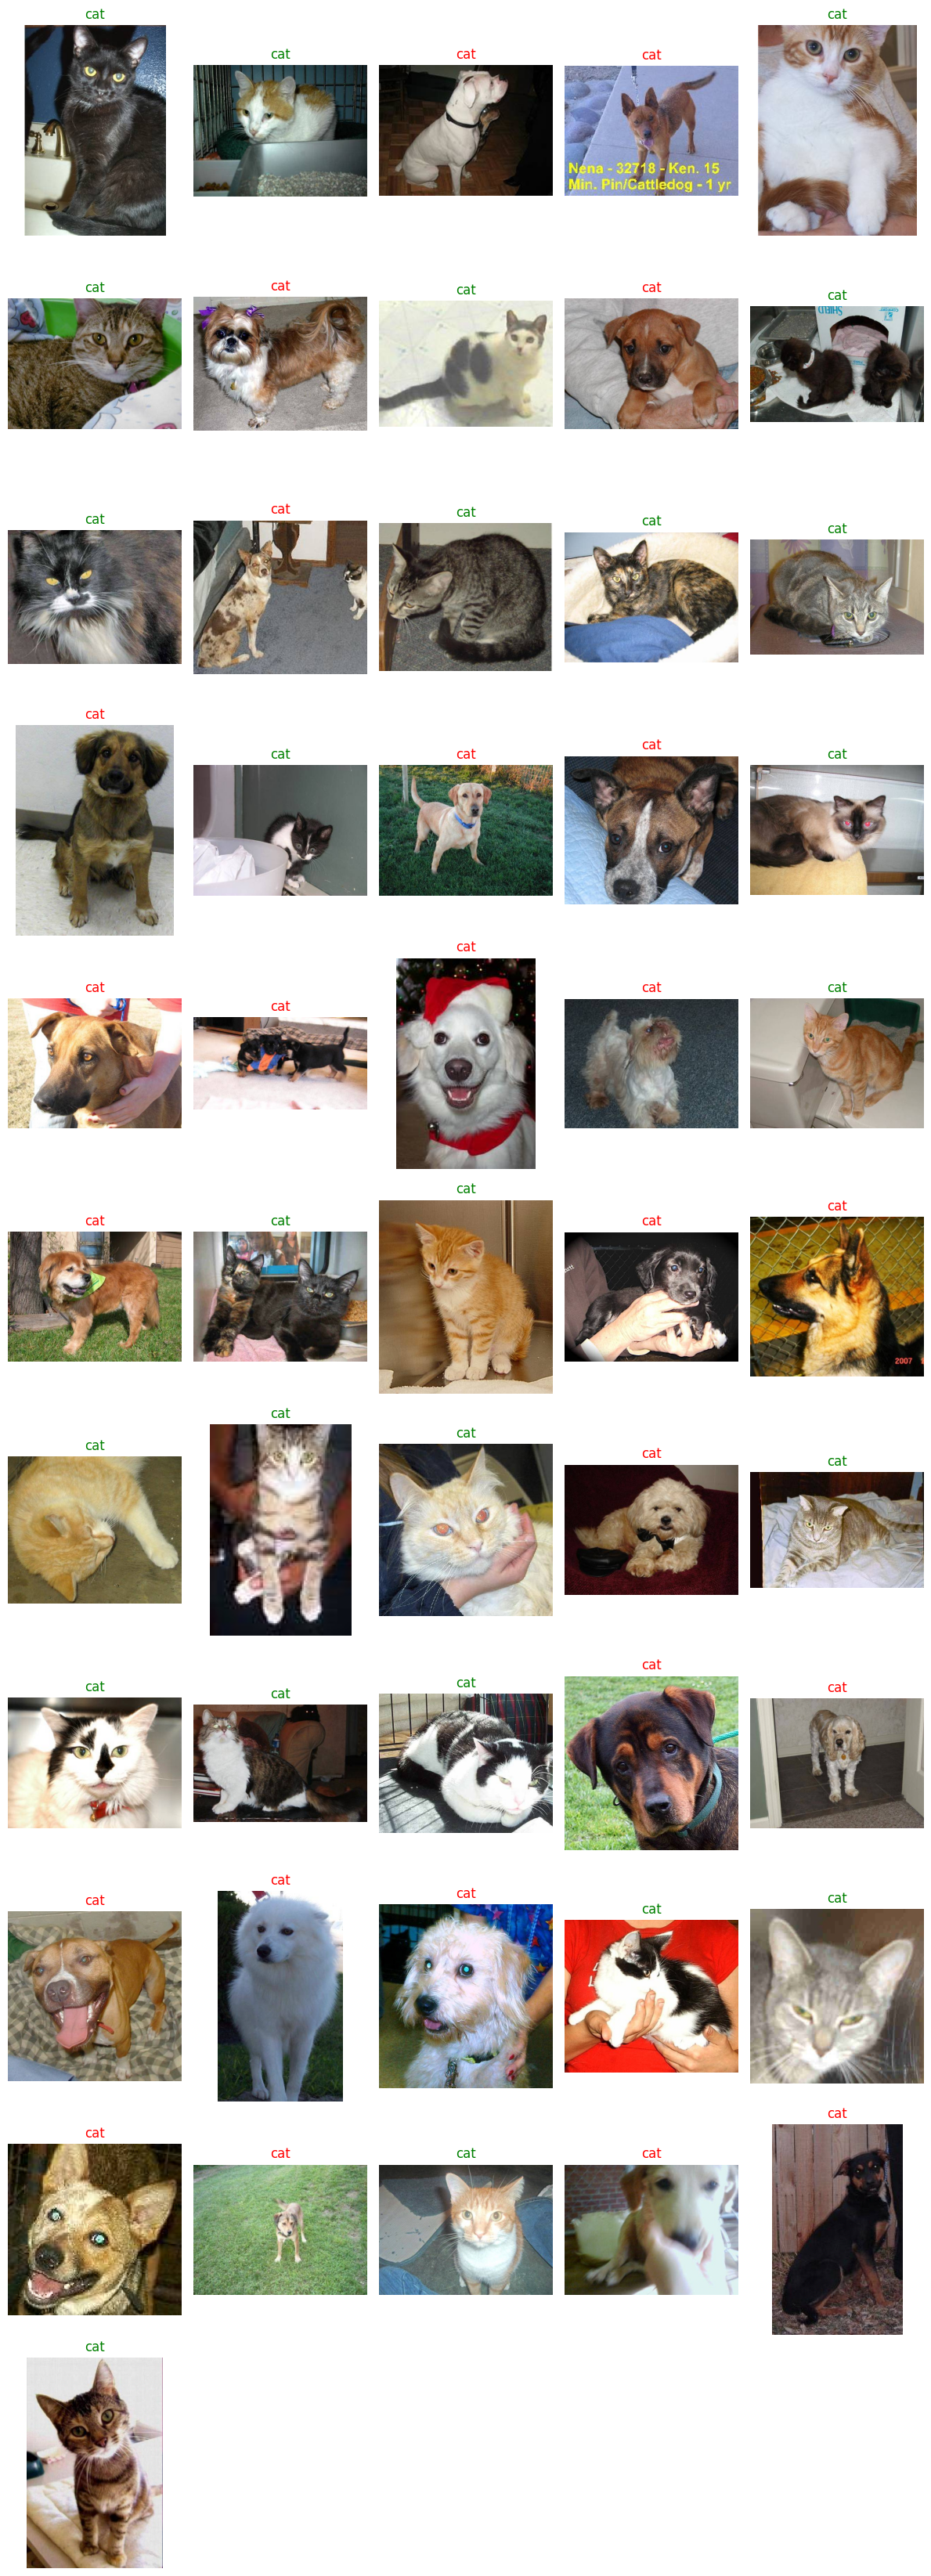

In [37]:
# res 데이터프레임에서 모델이 뱉어낸 라벨 리스트를 추출하여 함수에 전달
prediction_list = res['label'].tolist()
display_image_grid(test_images_filepaths, predicted_labels=prediction_list)

# 결론

| **모델명 (연도)** | **핵심 특징** | **의의 / 한계 극복** |
| --- | --- | --- |
| **LeNet-5** (1998) | Convolution + Pooling 구조 | CNN의 기본 틀 확립 |
| **AlexNet** (2012) | GPU 사용(병렬), ReLU, Dropout | 딥러닝 붐의 시발점 |
| **VGGNet** (2014) | 3x3 필터만 사용하여 깊게 구성 | 구조의 단순화, 여전히 높은 연산량 |
| **GoogLeNet** (2014) | **Inception 모듈 (1x1 conv로 차원 축소)** | **연산 효율성 극대화 (VGG보다 가벼움)** |
| **ResNet** (2015) | **Skip Connection (잔차 학습)** | 기울기 소실 극복, 100층 이상 레이어 가능 |